# House Prices Regression

## 1. Business Understanding

The real estate market depends heavily on accurate property price estimation.  
Incorrect pricing can lead to financial losses for sellers, buyers, real estate agents and investors.

The goal of this project is to build a Machine Learning model capable of predicting the final sale price of residential properties in Ames, Iowa, based on their physical, structural and location-related characteristics.

This project follows the CRISP-DM methodology and covers the main steps of a complete Data Science pipeline, including business understanding, data exploration, preprocessing, model training, evaluation, interpretation and deployment.

### Business Problem
How can we estimate the final sale price of a house based on its characteristics?

### Project Objective
Build a regression model to predict house sale prices using the Ames Housing dataset.

### Machine Learning Task
This is a supervised regression problem.

- Target variable: `SalePrice`
- Input variables: house characteristics such as area, quality, year built, neighborhood, garage size and others.
- Expected output: estimated sale price of a house.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split

In [2]:
warnings.filterwarnings("ignore", category=FutureWarning) # Hide FutureWarning messages generated by library compatibility issues

In [3]:
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [4]:
df = pd.read_csv('../input/AmesHousing.csv')
df = df.replace([np.inf, -np.inf], np.nan)
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df.shape

(2930, 82)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [7]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,2929.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2928.000000,2928.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2771.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,49.722431,559.262547,1051.614544,1159.557679,335.455973,4.676792,1499.690444,0.431352,0.061134,1.566553,0.379522,2.854266,1.044369,6.443003,0.599317,1978.132443,1.766815,472.819734,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,169.168476,439.494153,440.615067,391.890885,428.395715,46.310510,505.508887,0.524820,0.245254,0.552941,0.502629,0.827731,0.214076,1.572964,0.647921,25.528411,0.760566,215.046549,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,219.000000,793.000000,876.250000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,466.000000,990.000000,1084.000000,0.000000,0.000000,1442.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,0.000000,802.000000,1302.000000,1384.000000,703.750000,0.000000,1742.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [8]:
print(f'Duplicated rows: {df.duplicated().sum()}')
print(f'Missing values in SalePrice: {df["SalePrice"].isna().sum()}')

Duplicated rows: 0
Missing values in SalePrice: 0


In [9]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print(f'Numerical features: {len(numerical_features)}')
print(f'Categorical features: {len(categorical_features)}')


Numerical features: 39
Categorical features: 43


### Initial Data Overview

The dataset contains 2,930 rows and 82 columns.  
There are no duplicated rows and the target variable `SalePrice` has no missing values.

The dataset contains both numerical and categorical variables, which means that preprocessing steps such as missing value treatment, categorical encoding and feature scaling may be necessary before training machine learning models.

## 2. Train-Test Split

Before performing the full exploratory data analysis, the dataset will be split into training and test sets.

The training set will be used for data exploration, preprocessing decisions and model training.  
The test set will be kept untouched until the final model evaluation.

This approach helps prevent data leakage.

In [10]:
# Separar features e target

target = 'SalePrice'            # Definindo a variável alvo que queremos prever
X = df.drop(columns=[target])   # Cria a matriz de features removendo a variável alvo do dataset
y = df[target]                  # Cria o vetor da variável alvo com os preços das casas

print(f'X shape: {X.shape}')    # Exibe o tamanho da matriz de features
print(f'y shape: {y.shape}')    # Exibe o tamanho do vetor da variável alvo

X shape: (2930, 81)
y shape: (2930,)


In [11]:
# Divisão dos dados em treino e teste usando 80% para treino e 20% para teste

X_train, X_test, y_train, y_test = train_test_split(
    X,                                                  # Features do dataset
    y,                                                  # Variável alvo
    test_size=0.2,                                      # Definição de 20% para teste
    random_state=42                                     # Famoso 42
)

print(f'X_train shape: {X_train.shape}')                # Exibe o tamanho do conjunto de treino
print(f'X_test shape: {X_test.shape}')                  # Exibe o tamanho do conjunto de teste
print(f'y_train shape: {y_train.shape}')                # Exibe o tamanho da variável alvo de treino
print(f'y_test shape: {y_test.shape}')                  # Exibe o tamanho da variável alvo de teste

X_train shape: (2344, 81)
X_test shape: (586, 81)
y_train shape: (2344,)
y_test shape: (586,)


In [12]:
# Recriar uma base de treino para EDA e a base de testes para a avaliação final

train_data = X_train.copy()                         # Cria uma cópia do conjunto de treino para ser usada na EDA
train_data[target] = y_train                        # Acrescenta a variável alvo SalePrice de volta ao conjunto de treino

test_data = X_test.copy()                           # Cria uma cópia do conjunto de teste para ser usada na avaliação final
test_data[target] = y_test                          # Acrescenta a variável alvo SalePrice de volta ao conjunto de teste

print(f'Train data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')

Train data shape: (2344, 82)
Test data shape: (586, 82)


In [13]:
# Conferindo proporção da divisão

total_rows = df.shape[0]                            # Total de linhas do dataset original
train_ratio = train_data.shape[0]/total_rows        # Proporção dos dados utilizados para treino
test_ratio = test_data.shape[0]/total_rows          # Proporção dos dados utilizados para teste

print(f'Train ratio: {train_ratio:.2%}')
print(f'Test ratio: {test_ratio:.2%}')

Train ratio: 80.00%
Test ratio: 20.00%


### Train-Test Split Summary

The dataset was split into training and test sets using an 80/20 proportion.

- Training set: 2,344 rows
- Test set: 586 rows

From this point forward, the exploratory data analysis will be performed only on the training data.  
The test set will remain untouched until the final model evaluation stage.

## 3. Target Variable Analysis

In this section, we analyze the target variable `SalePrice`.

Understanding the target distribution is important because it helps identify patterns such as skewness, outliers and price concentration ranges.

All analyses from this point forward will be performed only on the training data to avoid data leakage.

In [14]:
# Display summary statistics for the target variable
train_data['SalePrice'].describe()

count      2344.000000
mean     178582.207765
std       77125.072713
min       12789.000000
25%      129000.000000
50%      160000.000000
75%      210000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [15]:
mean_price = train_data['SalePrice'].mean()         # Calculate the mean sale price
median_price = train_data['SalePrice'].median()     # Calculate the median sale price
skewness_price = train_data['SalePrice'].skew()     # Calculate the skewness of the sale price distribution

print(f'Mean SalePrice: ${mean_price:,.2f}')
print(f'Median SalePrice: ${median_price:,.2f}')
print(f'SalePrice Skewness: {skewness_price:.2f}')

Mean SalePrice: $178,582.21
Median SalePrice: $160,000.00
SalePrice Skewness: 1.75


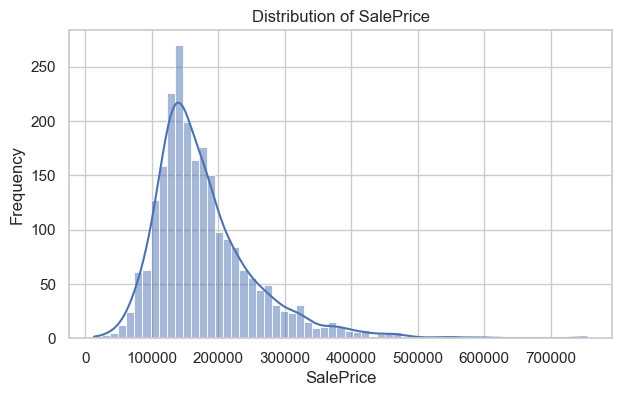

In [16]:
# SalePrice Distribution ; Histogram

plt.figure(figsize=(7,4))
sns.histplot(train_data['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

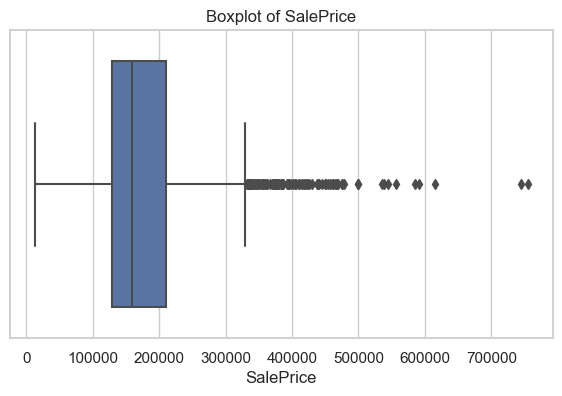

In [17]:
# SalePrice Boxplot

plt.figure(figsize=(7,4))
sns.boxplot(x=train_data['SalePrice'])
plt.title('Boxplot of SalePrice')
plt.xlabel('SalePrice')
plt.show()

In [18]:
# Verify Outliers using IQR

q1 = train_data['SalePrice'].quantile(0.25)     # first quartile of SalePrice
q3 = train_data['SalePrice'].quantile(0.75)     # third quartile of SalePrice
iqr = q3 - q1                                   # interquartile range

lower_limit = q1 - 1.5 * iqr                    # lower outlier limit
upper_limit = q3 + 1.5 * iqr                    # upper outlier limit

lower_outliers = train_data[train_data['SalePrice'] < lower_limit]
upper_outliers = train_data[train_data['SalePrice'] > upper_limit]

print(f'Lower limit: ${lower_limit:,.2f}')
print(f'Upper limit: ${upper_limit:,.2f}')
print(f'Lower outliers: {lower_outliers.shape[0]}')
print(f'Upper outliers: {upper_outliers.shape[0]}')

Lower limit: $7,500.00
Upper limit: $331,500.00
Lower outliers: 0
Upper outliers: 107


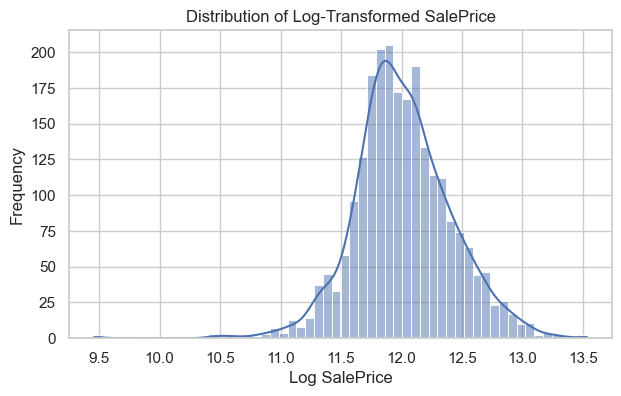

In [19]:
# Visualize log transformation

log_saleprice = np.log1p(train_data['SalePrice'])

plt.figure(figsize=(7,4))
sns.histplot(log_saleprice, kde=True)
plt.title('Distribution of Log-Transformed SalePrice')
plt.xlabel('Log SalePrice')
plt.ylabel('Frequency')
plt.show()

In [20]:
original_skewness = train_data['SalePrice'].skew()
log_skewness = log_saleprice.skew()
print(f'Original SalePrice Skewness: {original_skewness:.2f}')
print(f'Log-Transformed SalePrice Skewness: {log_skewness:.2f}')

Original SalePrice Skewness: 1.75
Log-Transformed SalePrice Skewness: -0.09


### Target Variable Insights

The target variable `SalePrice` presents a right-skewed distribution, as shown by the histogram and confirmed by the skewness value of 1.75. The mean sale price is higher than the median, indicating that expensive properties are pulling the average upward.

Using the IQR method, 107 observations were identified as potential upper outliers, while no lower outliers were found. However, these high-price observations should not be removed automatically, since they may represent legitimate expensive properties.

After applying a log transformation to `SalePrice`, the skewness decreased from 1.75 to -0.09, making the distribution much more symmetric. This suggests that a log transformation may be useful during the modeling stage.

## 4. Numerical Features Analysis

In this section, we analyze the numerical features in the training data.

The goal is to identify which numerical variables have the strongest relationship with the target variable `SalePrice`.

This analysis helps us understand the main price drivers and guides future steps such as feature selection, feature engineering and model building.

In [21]:
numeric_features = train_data.select_dtypes(include=['int64','float64'])
print(f'Number of numeric features: {numeric_features.shape[1]}')
numeric_features.columns

Number of numeric features: 39


Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold',
       'SalePrice'],
      dtype='object')

In [22]:
# Correlation

correlation_with_target = numeric_features.corr()['SalePrice'].sort_values(ascending=False)
correlation_with_target.head(15)

SalePrice         1.000000
Overall Qual      0.795298
Gr Liv Area       0.698315
Garage Cars       0.644304
Garage Area       0.633106
Total Bsmt SF     0.612256
1st Flr SF        0.607433
Year Built        0.545409
Full Bath         0.542053
Year Remod/Add    0.517653
Garage Yr Blt     0.516211
Mas Vnr Area      0.490912
TotRms AbvGrd     0.475455
Fireplaces        0.467501
BsmtFin SF 1      0.423906
Name: SalePrice, dtype: float64

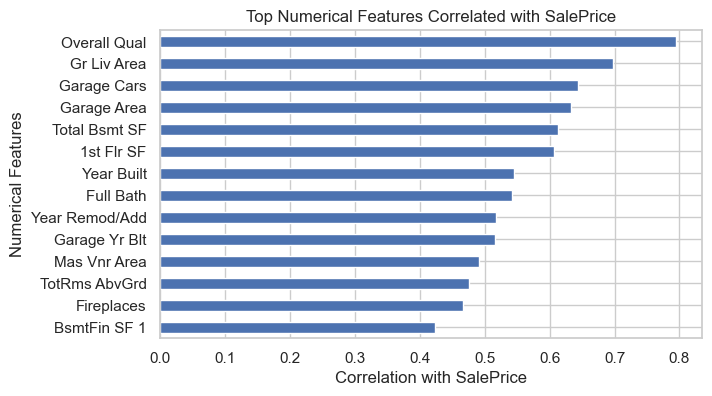

In [23]:
# Chart of the Strongest Correlations

top_corr_features = correlation_with_target.head(15).drop('SalePrice')

plt.figure(figsize=(7,4))
top_corr_features.sort_values().plot(kind='barh')
plt.title('Top Numerical Features Correlated with SalePrice')
plt.xlabel('Correlation with SalePrice')
plt.ylabel('Numerical Features')
plt.show()

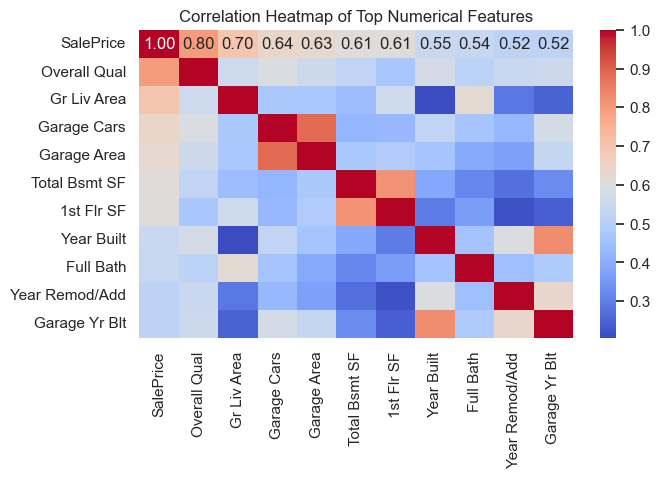

In [24]:
# Heatmap of the Main Numeric Variables

top_features = correlation_with_target.head(11).index

top_corr_matrix = train_data[top_features].corr()

plt.figure(figsize=(7,4))
sns.heatmap(
    top_corr_matrix,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm'
)
plt.title('Correlation Heatmap of Top Numerical Features')
plt.show()

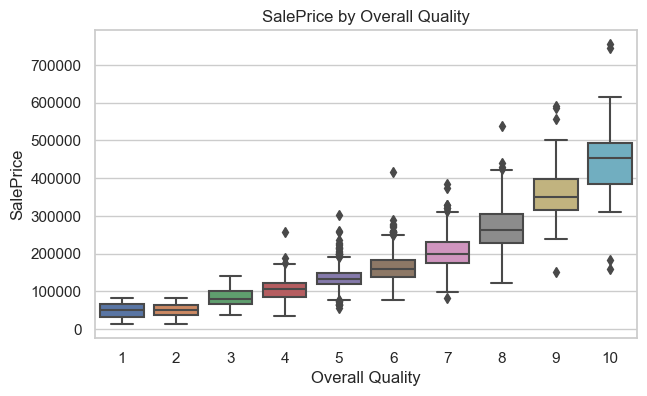

In [25]:
# Scatterplot: Overall Qual vs SalePrice

plt.figure(figsize=(7,4))
sns.boxplot(data = train_data, x = 'Overall Qual', y = 'SalePrice')
plt.title('SalePrice by Overall Quality')
plt.xlabel('Overall Quality')
plt.ylabel('SalePrice')
plt.show()

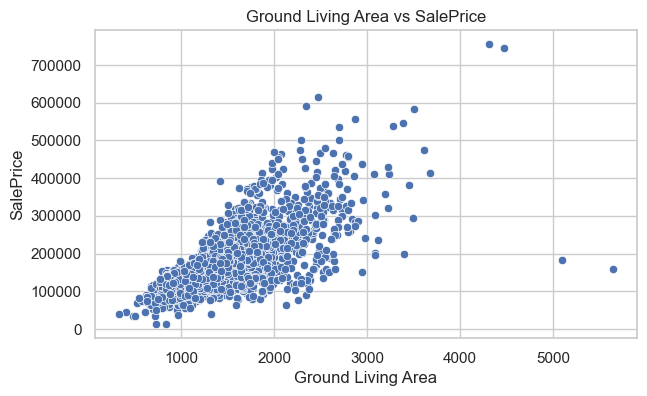

In [26]:
# Scatterplot: Gr Liv Area vs SalePrice

plt.figure(figsize=(7,4))
sns.scatterplot(data = train_data, x = 'Gr Liv Area', y = 'SalePrice')
plt.title('Ground Living Area vs SalePrice')
plt.xlabel('Ground Living Area')
plt.ylabel('SalePrice')
plt.show()

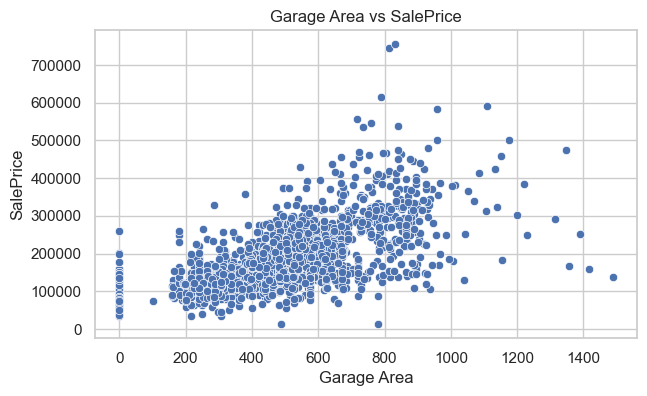

In [27]:
# Scatterplot: Garage Area vs SalePrice

plt.figure(figsize=(7,4))
sns.scatterplot(data = train_data, x = 'Garage Area', y = 'SalePrice')
plt.title('Garage Area vs SalePrice')
plt.xlabel('Garage Area')
plt.ylabel('SalePrice')
plt.show()

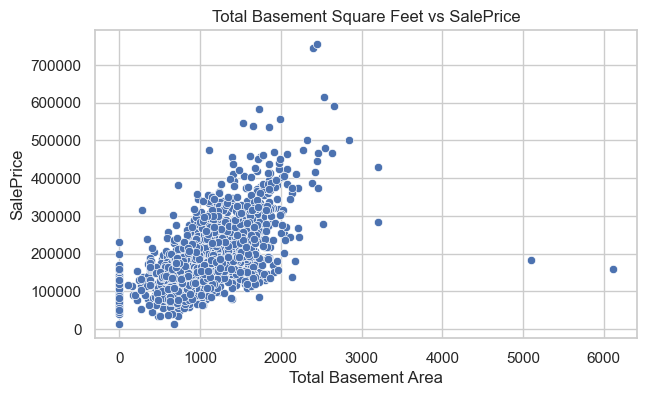

In [28]:
# Scatterplot: Total Basement Square Feet vs SalePrice

plt.figure(figsize=(7,4))
sns.scatterplot(data = train_data, x = 'Total Bsmt SF', y = 'SalePrice')
plt.title('Total Basement Square Feet vs SalePrice')
plt.xlabel('Total Basement Area')
plt.ylabel('SalePrice')
plt.show()

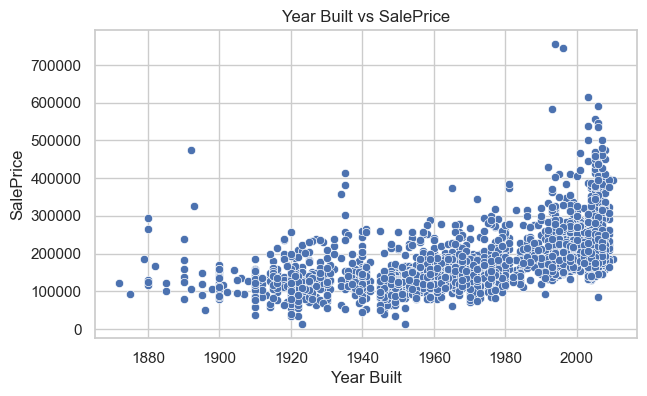

In [29]:
# Scatterplot: Year Built vs SalePrice

plt.figure(figsize=(7,4))
sns.scatterplot(data = train_data, x = 'Year Built', y = 'SalePrice')
plt.title('Year Built vs SalePrice')
plt.xlabel('Year Built')
plt.ylabel('SalePrice')
plt.show()

In [56]:
# Compare Average SalePrice by Overall Qual

overall_qual_summary = train_data.groupby('Overall Qual')['SalePrice'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

overall_qual_summary = overall_qual_summary.sort_index()
overall_qual_summary = overall_qual_summary.reset_index()
overall_qual_summary = overall_qual_summary.style.hide(axis='index').format({
    'count': '{:,.0f}',
    'mean': '{:,.2f}',
    'median': '{:,.2f}',
    'min': '{:,.2f}',
    'max': '{:,.2f}'
})

overall_qual_summary

Overall Qual,count,mean,median,min,max
1,4,"48,725.00","50,150.00","13,100.00","81,500.00"
2,10,"50,122.90","50,750.00","12,789.00","82,000.00"
3,30,"84,987.97","80,250.00","37,900.00","139,600.00"
4,177,"105,779.16","105,000.00","34,900.00","256,000.00"
5,675,"135,047.65","133,000.00","55,993.00","301,600.00"
6,613,"162,512.76","160,000.00","76,000.00","415,000.00"
7,465,"204,048.49","200,000.00","82,500.00","383,970.00"
8,267,"269,359.02","263,550.00","122,000.00","538,000.00"
9,81,"360,129.68","350,000.00","150,000.00","591,587.00"
10,22,"449,028.23","453,475.00","160,000.00","755,000.00"


### Numerical Features Insights

The numerical feature most correlated with `SalePrice` is `Overall Qual`, indicating that the overall material and finish quality of the house is one of the strongest price drivers.

`Gr Liv Area`, which represents the above-ground living area, also shows a strong positive relationship with house prices. This suggests that larger houses tend to be more expensive.

Garage-related features, such as `Garage Cars` and `Garage Area`, are also highly correlated with `SalePrice`, indicating that garage capacity and size add value to the property.

Basement area, first floor area, construction year and number of bathrooms also show relevant positive correlations with the target variable.

Some numerical features may be strongly correlated with each other, such as `Garage Cars` and `Garage Area`. This will be considered later during preprocessing and model selection.

## 5. Categorical Features Analysis

In this section, we analyze categorical features and their relationship with the target variable `SalePrice`.

Categorical variables are important because they may represent location, house style, material quality, garage type, basement quality and sale conditions.

The goal is to identify which categories are associated with higher or lower house prices.

In [48]:
# Select categorical features

categorical_features = train_data.select_dtypes(['object']).columns         # Select only categorical columns from the training dataset
print(f'Number of categorical features: {len(categorical_features)}')       # Display the number of categorical features
categorical_features

Number of categorical features: 43


Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')

In [50]:
# Number of Categories per Variable

categorical_summary = pd.DataFrame({
    'Feature': categorical_features,
    'Unique Values': [train_data[col].nunique(dropna=False) for col in categorical_features],
    'Missing Values': [train_data[col].isna().sum() for col in categorical_features]
})

categorical_summary = categorical_summary.sort_values(by="Unique Values", ascending=False)
categorical_summary


,Feature,Unique Values,Missing Values
8,Neighborhood,28,0
16,Exterior 2nd,16,0
15,Exterior 1st,16,0
41,Sale Type,10,0
9,Condition 1,9,0
12,House Style,8,0
14,Roof Matl,8,0
31,Functional,8,0
10,Condition 2,8,0
24,BsmtFin Type 1,7,61


In [57]:
# Average SalePrice by Neighborhood

neighborhood_summary = train_data.groupby('Neighborhood')['SalePrice'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

neighborhood_summary = neighborhood_summary.sort_values(by='median', ascending=False)

neighborhood_summary

,count,mean,median,min,max
Neighborhood,,,,,
NridgHt,121,312743.578512,316000.0,154000,615000
NoRidge,57,330866.807018,301500.0,190000,755000
StoneBr,36,326523.444444,298950.0,130000,591587
GrnHill,2,280000.000000,280000.0,230000,330000
Veenker,22,251115.909091,250250.0,150000,385000
Timber,59,240096.050847,228000.0,137500,425000
Somerst,136,226000.948529,220500.0,139000,468000
Greens,7,194321.428571,206000.0,155000,214000
CollgCr,211,200844.829384,200141.0,110000,475000


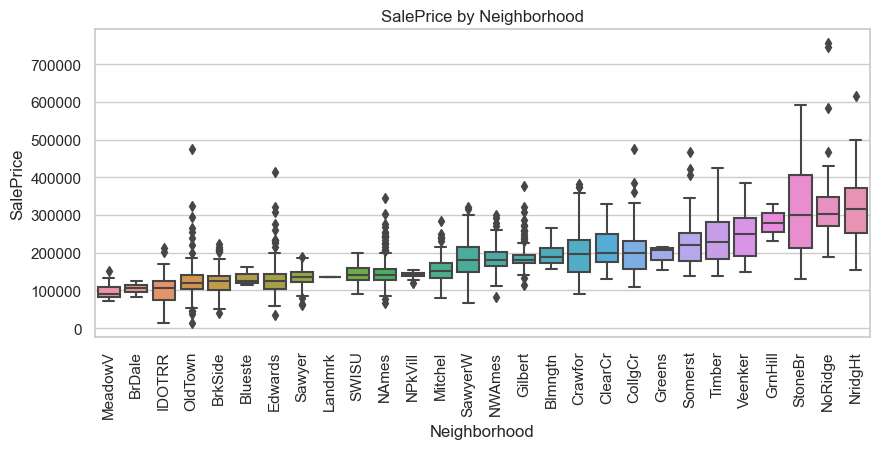

In [62]:
# Boxplot SalePrice by Neighborhood

neighborhood_order = train_data.groupby('Neighborhood')['SalePrice'].median().sort_values().index

plt.figure(figsize=(10,4))
sns.boxplot(
    data = train_data,
    x = 'Neighborhood',
    y = 'SalePrice',
    order=neighborhood_order
)
plt.title('SalePrice by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('SalePrice')
plt.xticks(rotation=90)
plt.show()

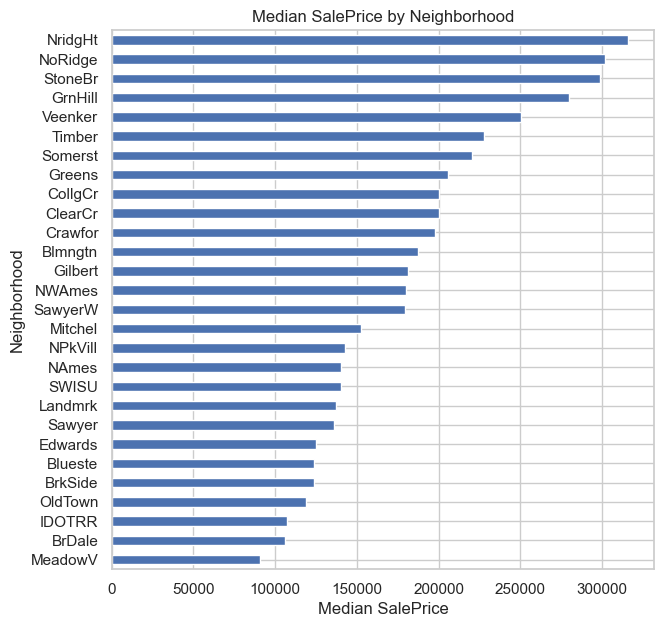

In [65]:
# Median price by Neighborhood

neighborhood_median_price = train_data.groupby('Neighborhood')['SalePrice'].median().sort_values()

plt.figure(figsize=(7,7))
neighborhood_median_price.plot(kind='barh')
plt.title('Median SalePrice by Neighborhood')
plt.xlabel('Median SalePrice')
plt.ylabel('Neighborhood')
plt.show()